# 📉 CLV Decay Forecast — BG/NBD Forward Projection
**LushProtein Analytics | Medallion Architecture**

Extends the static BG/NBD P_Alive snapshot from `04_ds3-1_channel_heterogeneity` into a **forward-looking revenue decay curve**.

| Model | Output |
|---|---|
| BG/NBD (Beta-Geo/NBD) | Expected purchases per customer at t = 30 / 60 / 90 / 180 / 365 days |
| Gamma-Gamma | Expected AOV per customer (repeat-order value) |
| Combined | Expected revenue decay curve by channel (Analysis A) and SG/MY country (Analysis B) |

> **What this answers:** If we do nothing, how much revenue should we expect from the current customer base over the next 30 / 60 / 90 / 180 / 365 days — and which segments decay fastest?


## 0. Setup & Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from lifetimes import BetaGeoFitter, GammaGammaFitter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

BASE_DIR   = Path('.')
GOLD_DIR   = BASE_DIR / 'medallion' / 'gold'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

COLORS_CHANNEL = {
    'DTC'            : '#3BB273',
    'Lazada'         : '#2E86AB',
    'Shopee'         : '#F97316',
    'Social Referral': '#E84855',
}
COLORS_COUNTRY = {'SG': '#2E86AB', 'MY': '#3BB273', 'Other': '#A8A8A8'}

HORIZONS       = [30, 60, 90, 180, 365]
HORIZON_LABELS = ['30d', '60d', '90d', '180d', '365d']
HORIZON_DAYS   = dict(zip(HORIZON_LABELS, HORIZONS))

sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

Setup complete.


---
## 1. Load & Prepare RFM Data

In [2]:
# Load gold tables
co = pd.read_parquet(GOLD_DIR / 'gold_customer_orders.parquet')
cp = pd.read_parquet(GOLD_DIR / 'gold_customer_profiles.parquet')

# Exclude known B2B outlier (inflates average order value)
B2B_OUTLIER = '7888450879743'
co_clean = co[co['customer_id'] != B2B_OUTLIER].copy()
co_paid  = co_clean[co_clean['payment_status'] == 'paid'].copy()
co_paid['processed_at']       = pd.to_datetime(co_paid['processed_at'], errors='coerce', utc=True)
co_paid['processed_at_naive'] = co_paid['processed_at'].dt.tz_localize(None)

# ── Channel classification (same rules as 04_ds3-1) ─────────────────────────
social_sources  = ['facebook', 'meta', 'ig', 'igshopping', 'tiktok', 'snowball', 'igpost', 'affiliate']
social_mediums  = ['paid_social', 'social', 'instagram_stories', 'referral_url', 'affiliate']
social_channels = ['TikTok', 'Affiliate']

first_orders = co_paid[co_paid['order_sequence'] == 1][[
    'customer_id', 'processed_at_naive', 'channel',
    'utm_source', 'utm_medium', 'price_total'
]].rename(columns={'processed_at_naive': 'first_order_date',
                   'price_total'        : 'first_order_spend'}).copy()

# Fill NaN utm fields before string operations
first_orders['utm_source'] = first_orders['utm_source'].fillna('')
first_orders['utm_medium'] = first_orders['utm_medium'].fillna('')

is_social = (
    first_orders['channel'].isin(social_channels) |
    first_orders['utm_source'].str.lower().isin(social_sources) |
    first_orders['utm_medium'].str.lower().isin(social_mediums)
)
first_orders['acquisition_channel'] = np.where(
    is_social, 'Social Referral', first_orders['channel'])

TARGET_CHANNELS = ['DTC', 'Lazada', 'Shopee', 'Social Referral']
first_orders = first_orders[
    first_orders['acquisition_channel'].isin(TARGET_CHANNELS)].copy()

# ── Add country from gold_customer_profiles ──────────────────────────────────
def map_country(c):
    if pd.isna(c): return 'Other'
    c = str(c).upper().strip()
    if c in ('SG', 'SGP'): return 'SG'
    if c in ('MY', 'MYS'): return 'MY'
    return 'Other'

cp_country = cp[['customer_id', 'acquisition_country']].copy()
cp_country['country'] = cp_country['acquisition_country'].apply(map_country)
first_orders = first_orders.merge(
    cp_country[['customer_id', 'country']], on='customer_id', how='left')
first_orders['country'] = first_orders['country'].fillna('Other')

# ── Build RFM table ──────────────────────────────────────────────────────────
co_model = co_paid[
    co_paid['customer_id'].isin(first_orders['customer_id'])].copy()
obs_date = co_model['processed_at_naive'].max()

rfm = co_model.groupby('customer_id').agg(
    last_order_date=('processed_at_naive', 'max'),
    AOF            =('order_id', lambda x: len(x) - 1),
    total_spend    =('price_total', 'sum'),
).reset_index()

rfm = rfm.merge(
    first_orders[['customer_id', 'first_order_date', 'first_order_spend',
                  'acquisition_channel', 'country']],
    on='customer_id', how='inner')

rfm['recency_days'] = (
    rfm['last_order_date'] - rfm['first_order_date']).dt.days
rfm['tenure_days']  = (
    obs_date - rfm['first_order_date']).dt.days
rfm['repeat_spend'] = rfm['total_spend'] - rfm['first_order_spend']
rfm['AOV']          = np.where(
    rfm['AOF'] > 0, rfm['repeat_spend'] / rfm['AOF'], 0)

print(f'Model dataset  : {len(rfm):,} customers')
print(f'Observation date: {obs_date.date()}')
print(f'\nChannel breakdown:')
print(rfm['acquisition_channel'].value_counts().to_string())
print(f'\nCountry breakdown:')
print(rfm['country'].value_counts().to_string())

Model dataset  : 9,941 customers
Observation date: 2026-03-31

Channel breakdown:
acquisition_channel
DTC                4849
Lazada             3658
Social Referral     754
Shopee              680

Country breakdown:
country
MY       4805
SG       4481
Other     655


---
## 2. Fit BG/NBD & Gamma-Gamma Models

In [3]:
# ── BG/NBD ──────────────────────────────────────────────────────────────────
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(rfm['AOF'], rfm['recency_days'], rfm['tenure_days'])

print('BG/NBD fitted.')
print(f'  r     = {bgf.params_["r"]:.4f}')
print(f'  alpha = {bgf.params_["alpha"]:.4f}')
print(f'  a     = {bgf.params_["a"]:.4f}')
print(f'  b     = {bgf.params_["b"]:.4f}')

# ── Gamma-Gamma ──────────────────────────────────────────────────────────────
gg_df = rfm[(rfm['AOF'] > 0) & (rfm['AOV'] > 0)].copy()
ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(gg_df['AOF'], gg_df['AOV'])

print(f'\nGamma-Gamma fitted (on {len(gg_df):,} repeat buyers).')
print(f'  p = {ggf.params_["p"]:.4f}')
print(f'  q = {ggf.params_["q"]:.4f}')
print(f'  v = {ggf.params_["v"]:.4f}')

# Expected AOV for all customers
rfm['expected_aov'] = ggf.conditional_expected_average_profit(
    rfm['AOF'], rfm['AOV'])
rfm['p_alive'] = bgf.conditional_probability_alive(
    rfm['AOF'], rfm['recency_days'], rfm['tenure_days'])

print(f'\nCurrent P_Alive (mean): {rfm["p_alive"].mean():.3f}')
print(f'Current P_Alive by channel:')
print(rfm.groupby('acquisition_channel')['p_alive']
        .agg(['mean', 'median']).round(3).to_string())

BG/NBD fitted.
  r     = 0.0892
  alpha = 5.0071
  a     = 1.7377
  b     = 2.8898

Gamma-Gamma fitted (on 3,485 repeat buyers).
  p = 2.7102
  q = 1.9892
  v = 50.1945

Current P_Alive (mean): 0.707
Current P_Alive by channel:
                     mean  median
acquisition_channel              
DTC                  0.73    1.00
Lazada               0.62    1.00
Shopee               0.88    1.00
Social Referral      0.85    1.00


---
## 3. Forward Projection at 30 / 60 / 90 / 180 / 365 Days

In [4]:
# For each horizon t, compute per-customer expected purchases and expected revenue
for t, label in zip(HORIZONS, HORIZON_LABELS):
    rfm[f'exp_purchases_{label}'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        t, rfm['AOF'], rfm['recency_days'], rfm['tenure_days'])
    rfm[f'exp_revenue_{label}'] = rfm[f'exp_purchases_{label}'] * rfm['expected_aov']
    # Survival proxy: P(at least 1 purchase in next t days) ≈ 1 - exp(-E[X(t)])
    rfm[f'p_active_{label}'] = 1 - np.exp(-rfm[f'exp_purchases_{label}'])

print('Forward projections computed.')
print('\nAggregate summary — all channels combined:')
rows = []
for t, label in zip(HORIZONS, HORIZON_LABELS):
    total_rev = rfm[f'exp_revenue_{label}'].sum()
    pct_active = rfm[f'p_active_{label}'].mean()
    monthly_rate = total_rev / t * 30
    rows.append({'Horizon': label, 'Expected Revenue (SGD)': total_rev,
                 'Monthly Rate (SGD)': monthly_rate,
                 '% Likely to Transact': pct_active})
agg = pd.DataFrame(rows).set_index('Horizon')
agg['Expected Revenue (SGD)'] = agg['Expected Revenue (SGD)'].apply(lambda x: f'{x:,.0f}')
agg['Monthly Rate (SGD)']     = agg['Monthly Rate (SGD)'].apply(lambda x: f'{x:,.0f}')
agg['% Likely to Transact']   = agg['% Likely to Transact'].apply(lambda x: f'{x:.1%}')
display(agg)

Forward projections computed.

Aggregate summary — all channels combined:


,Expected Revenue (SGD),Monthly Rate (SGD),% Likely to Transact
Horizon,,,
30d,"23,584","23,584",1.8%
60d,"43,290","21,645",3.2%
90d,"60,934","20,311",4.3%
180d,"106,494","17,749",6.8%
365d,"181,024","14,879",10.3%


---
## 4A. Channel Decay — Customer Survival & Revenue

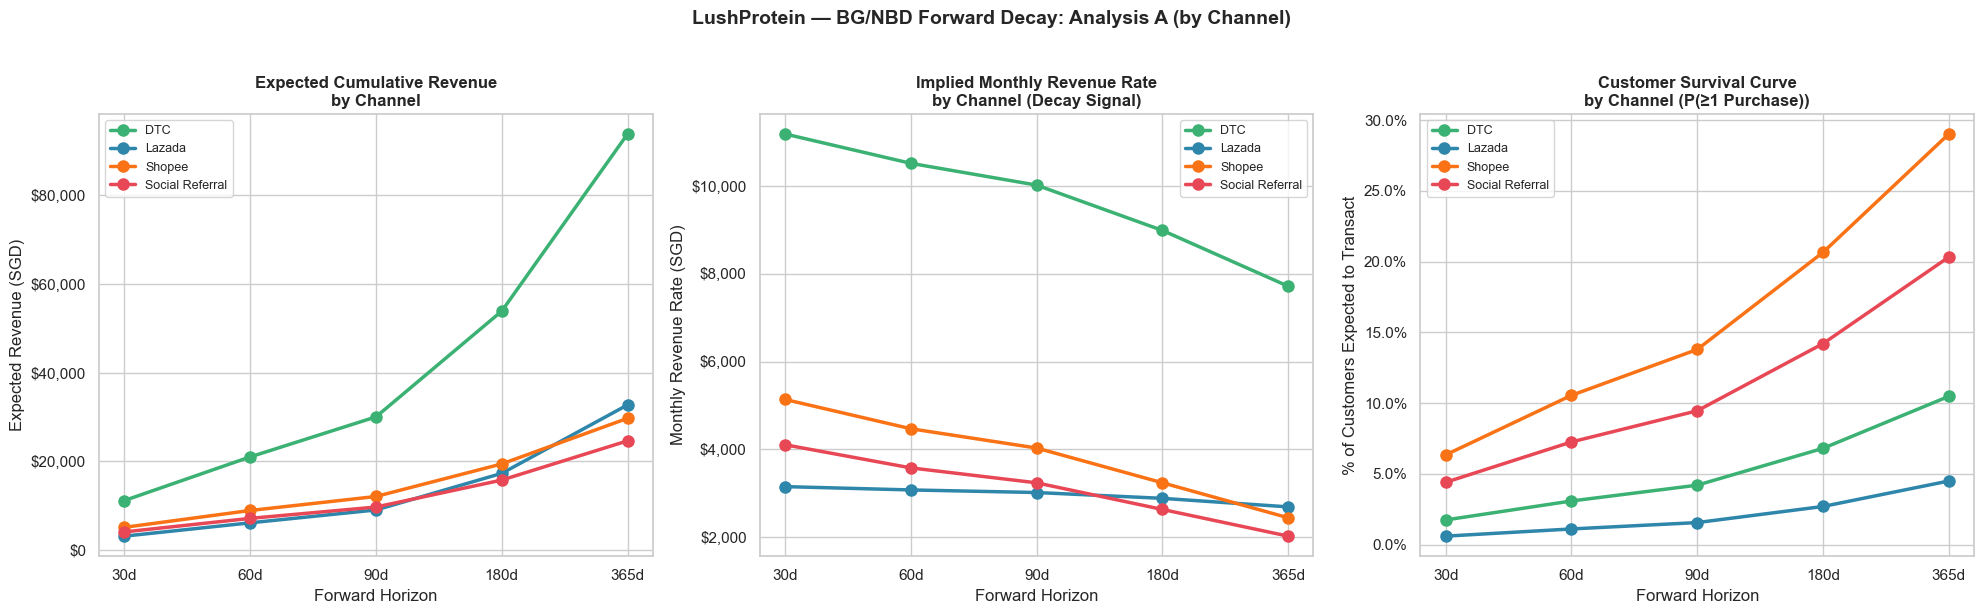

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Panel 1: Expected cumulative revenue by channel ──────────────────────────
ax1 = axes[0]
for ch, color in COLORS_CHANNEL.items():
    sub = rfm[rfm['acquisition_channel'] == ch]
    revenues = [sub[f'exp_revenue_{lbl}'].sum() for lbl in HORIZON_LABELS]
    ax1.plot(HORIZON_LABELS, revenues, marker='o', linewidth=2.5,
             markersize=8, label=ch, color=color)
ax1.set_title('Expected Cumulative Revenue\nby Channel', fontsize=12, fontweight='bold')
ax1.set_xlabel('Forward Horizon')
ax1.set_ylabel('Expected Revenue (SGD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)

# ── Panel 2: Monthly revenue run rate by channel (decay signal) ──────────────
ax2 = axes[1]
for ch, color in COLORS_CHANNEL.items():
    sub = rfm[rfm['acquisition_channel'] == ch]
    rates = [sub[f'exp_revenue_{lbl}'].sum() / HORIZON_DAYS[lbl] * 30
             for lbl in HORIZON_LABELS]
    ax2.plot(HORIZON_LABELS, rates, marker='o', linewidth=2.5,
             markersize=8, label=ch, color=color)
ax2.set_title('Implied Monthly Revenue Rate\nby Channel (Decay Signal)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Forward Horizon')
ax2.set_ylabel('Monthly Revenue Rate (SGD)')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=9)

# ── Panel 3: Survival curve — % customers expected to transact by channel ─────
ax3 = axes[2]
for ch, color in COLORS_CHANNEL.items():
    sub = rfm[rfm['acquisition_channel'] == ch]
    pct = [sub[f'p_active_{lbl}'].mean() * 100 for lbl in HORIZON_LABELS]
    ax3.plot(HORIZON_LABELS, pct, marker='o', linewidth=2.5,
             markersize=8, label=ch, color=color)
ax3.set_title('Customer Survival Curve\nby Channel (P(≥1 Purchase))', fontsize=12, fontweight='bold')
ax3.set_xlabel('Forward Horizon')
ax3.set_ylabel('% of Customers Expected to Transact')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.legend(fontsize=9)

plt.suptitle('LushProtein — BG/NBD Forward Decay: Analysis A (by Channel)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clv_decay_channel.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Channel decay summary table
print('=== Channel Decay Summary ===')
rows = []
for ch in TARGET_CHANNELS:
    sub = rfm[rfm['acquisition_channel'] == ch]
    row = {'Channel': ch, 'Customers': len(sub)}
    for lbl in HORIZON_LABELS:
        row[f'Rev {lbl} (SGD)'] = sub[f'exp_revenue_{lbl}'].sum()
        row[f'Alive {lbl}'] = sub[f'p_active_{lbl}'].mean()
    rows.append(row)
summary_ch = pd.DataFrame(rows).set_index('Channel')

# Monthly rate decay: ratio of 365d monthly rate vs 30d monthly rate
for ch in TARGET_CHANNELS:
    sub = rfm[rfm['acquisition_channel'] == ch]
    rate_30  = sub['exp_revenue_30d'].sum() / 30 * 30
    rate_365 = sub['exp_revenue_365d'].sum() / 365 * 30
    decay_pct = (rate_30 - rate_365) / rate_30 * 100 if rate_30 > 0 else 0
    print(f'{ch:20s}: 30d monthly rate SGD {rate_30:>10,.0f} → 365d rate SGD {rate_365:>10,.0f}  '
          f'(decay {decay_pct:.1f}%)')

=== Channel Decay Summary ===
DTC                 : 30d monthly rate SGD     11,184 → 365d rate SGD      7,716  (decay 31.0%)
Lazada              : 30d monthly rate SGD      3,154 → 365d rate SGD      2,693  (decay 14.6%)
Shopee              : 30d monthly rate SGD      5,139 → 365d rate SGD      2,444  (decay 52.4%)
Social Referral     : 30d monthly rate SGD      4,107 → 365d rate SGD      2,026  (decay 50.7%)


---
## 4B. SG/MY Decay — Customer Survival & Revenue

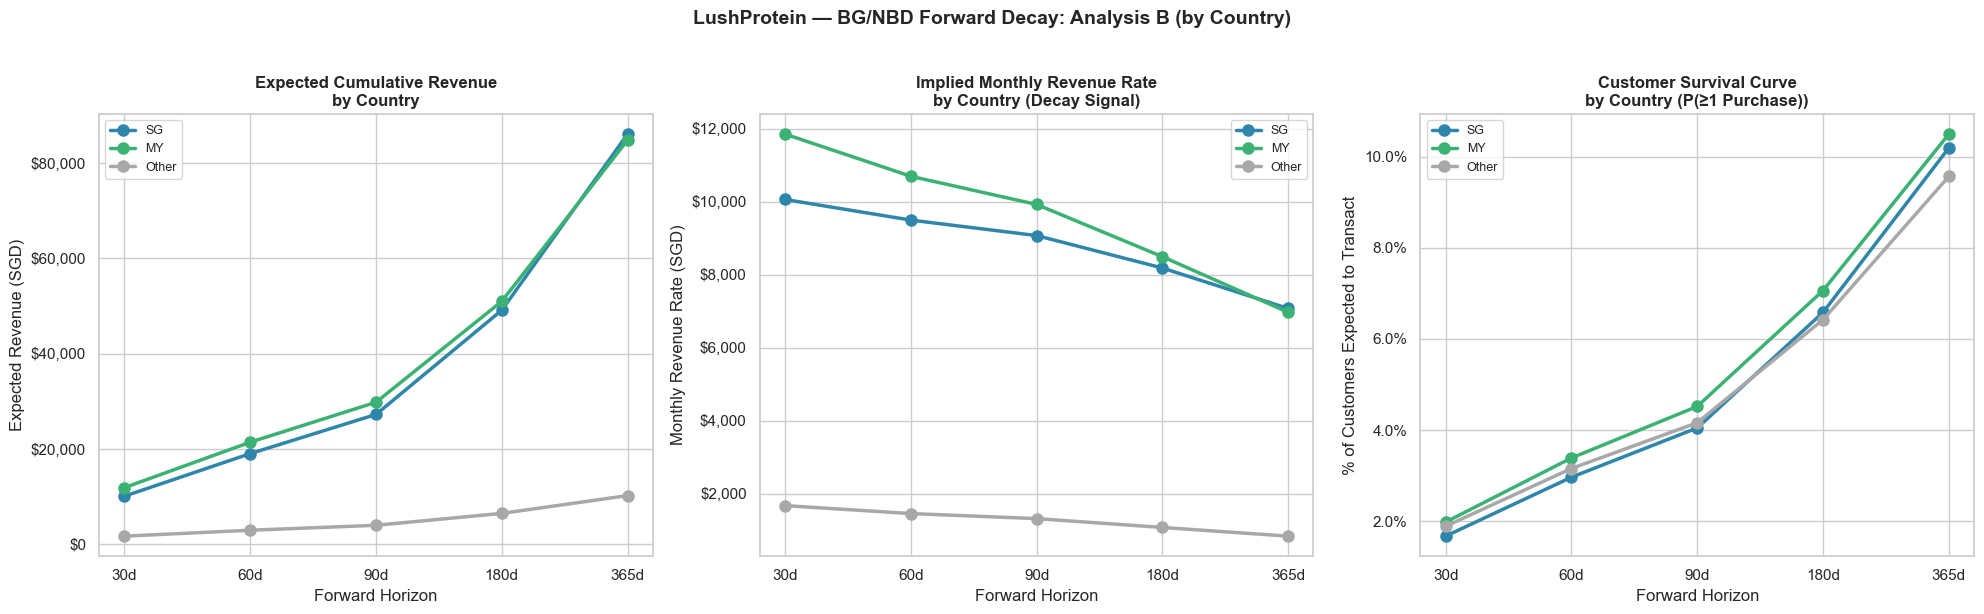

In [7]:
COUNTRY_ORDER = ['SG', 'MY', 'Other']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Panel 1: Expected cumulative revenue by country ──────────────────────────
ax1 = axes[0]
for ctry, color in COLORS_COUNTRY.items():
    sub = rfm[rfm['country'] == ctry]
    if len(sub) == 0: continue
    revenues = [sub[f'exp_revenue_{lbl}'].sum() for lbl in HORIZON_LABELS]
    ax1.plot(HORIZON_LABELS, revenues, marker='o', linewidth=2.5,
             markersize=8, label=ctry, color=color)
ax1.set_title('Expected Cumulative Revenue\nby Country', fontsize=12, fontweight='bold')
ax1.set_xlabel('Forward Horizon')
ax1.set_ylabel('Expected Revenue (SGD)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)

# ── Panel 2: Monthly revenue run rate by country (decay signal) ──────────────
ax2 = axes[1]
for ctry, color in COLORS_COUNTRY.items():
    sub = rfm[rfm['country'] == ctry]
    if len(sub) == 0: continue
    rates = [sub[f'exp_revenue_{lbl}'].sum() / HORIZON_DAYS[lbl] * 30
             for lbl in HORIZON_LABELS]
    ax2.plot(HORIZON_LABELS, rates, marker='o', linewidth=2.5,
             markersize=8, label=ctry, color=color)
ax2.set_title('Implied Monthly Revenue Rate\nby Country (Decay Signal)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Forward Horizon')
ax2.set_ylabel('Monthly Revenue Rate (SGD)')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=9)

# ── Panel 3: Survival curve — % customers expected to transact by country ──────
ax3 = axes[2]
for ctry, color in COLORS_COUNTRY.items():
    sub = rfm[rfm['country'] == ctry]
    if len(sub) == 0: continue
    pct = [sub[f'p_active_{lbl}'].mean() * 100 for lbl in HORIZON_LABELS]
    ax3.plot(HORIZON_LABELS, pct, marker='o', linewidth=2.5,
             markersize=8, label=ctry, color=color)
ax3.set_title('Customer Survival Curve\nby Country (P(≥1 Purchase))', fontsize=12, fontweight='bold')
ax3.set_xlabel('Forward Horizon')
ax3.set_ylabel('% of Customers Expected to Transact')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.legend(fontsize=9)

plt.suptitle('LushProtein — BG/NBD Forward Decay: Analysis B (by Country)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clv_decay_country.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Country decay summary table
print('=== Country Decay Summary ===')
for ctry in COUNTRY_ORDER:
    sub = rfm[rfm['country'] == ctry]
    if len(sub) == 0: continue
    rate_30  = sub['exp_revenue_30d'].sum() / 30 * 30
    rate_365 = sub['exp_revenue_365d'].sum() / 365 * 30
    decay_pct = (rate_30 - rate_365) / rate_30 * 100 if rate_30 > 0 else 0
    print(f'{ctry:10s} (n={len(sub):,}): 30d rate SGD {rate_30:>10,.0f} → '
          f'365d rate SGD {rate_365:>10,.0f}  (decay {decay_pct:.1f}%)')

=== Country Decay Summary ===
SG         (n=4,481): 30d rate SGD     10,059 → 365d rate SGD      7,073  (decay 29.7%)
MY         (n=4,805): 30d rate SGD     11,851 → 365d rate SGD      6,969  (decay 41.2%)
Other      (n=655): 30d rate SGD      1,674 → 365d rate SGD        837  (decay 50.0%)


---
## 5. Revenue at Risk Summary

=== Revenue at Risk by Segment ===
(Difference between near-term and long-term monthly revenue run rate)



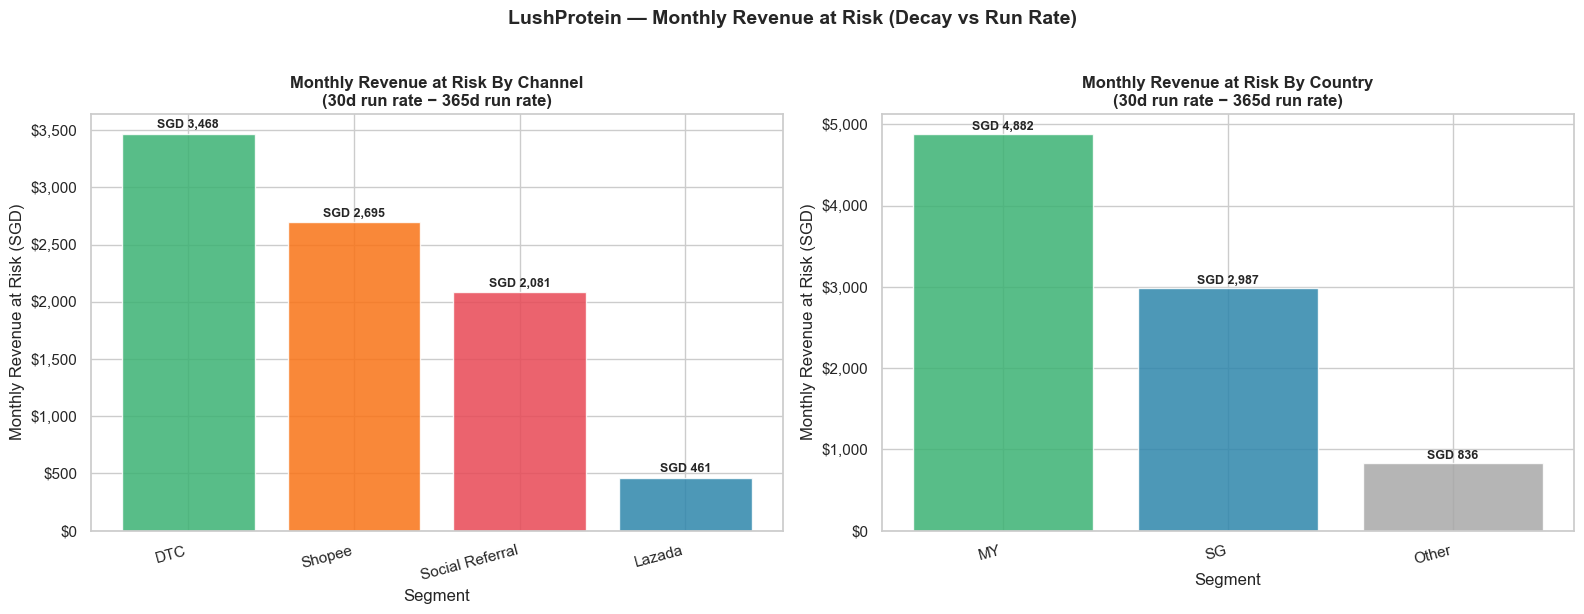

In [9]:
# Revenue at risk = expected 30-day run rate − expected 365-day run rate
# (how much monthly revenue is being 'lost' as the customer base decays)
print('=== Revenue at Risk by Segment ===')
print('(Difference between near-term and long-term monthly revenue run rate)\n')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, groupby, colors, title in [
    (axes[0], 'acquisition_channel', COLORS_CHANNEL, 'By Channel'),
    (axes[1], 'country',              COLORS_COUNTRY,  'By Country'),
]:
    risk_rows = []
    for key, sub in rfm.groupby(groupby):
        rate_30  = sub['exp_revenue_30d'].sum()  / 30  * 30
        rate_180 = sub['exp_revenue_180d'].sum() / 180 * 30
        rate_365 = sub['exp_revenue_365d'].sum() / 365 * 30
        risk = rate_30 - rate_365
        risk_rows.append({'Segment': key, 'Rate_30d': rate_30,
                          'Rate_365d': rate_365, 'Revenue_at_Risk': risk})
    risk_df = pd.DataFrame(risk_rows).sort_values('Revenue_at_Risk', ascending=False)

    bar_colors = [colors.get(s, '#A8A8A8') for s in risk_df['Segment']]
    bars = ax.bar(risk_df['Segment'], risk_df['Revenue_at_Risk'],
                  color=bar_colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, risk_df['Revenue_at_Risk']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 50,
                f'SGD {val:,.0f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Monthly Revenue at Risk {title}\n(30d run rate − 365d run rate)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Segment')
    ax.set_ylabel('Monthly Revenue at Risk (SGD)')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.suptitle('LushProtein — Monthly Revenue at Risk (Decay vs Run Rate)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clv_revenue_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()